# Right-Censored Post-IPCW Comparison

This notebook mirrors the local warm-start demo structure, but now keeps both fixed and CV-tuned post-IPCW refinements in the same comparison:

- `CV-IPCW`: the shared Stage 1 initializer
- `EM`: inherited-constraint EM refinement after the Stage 1 IPCW fit
- `CVEM`: CV-tuned EM refinement on the post-IPCW norm path
- `L1MLE`: inherited-constraint observed-data fixed-support L1 refit
- `CVL1MLE`: CV-tuned observed-data fixed-support L1 refit on the same norm path

The event-time data-generating process is a truncated normal on `[0, 1]` with independent uniform censoring. Both `CVEM` and `CVL1MLE` are tuned on the same deterministic norm-multiplier grid over `[1, 2]`, while `EM` and `L1MLE` serve as the fixed factor-1.0 baselines.

## Run Configuration

This notebook keeps the same Stage 1 IPCW setup as the existing local demo, then compares fixed and CV-tuned second-stage refinements on the shared post-IPCW norm-multiplier path.

In [1]:
from __future__ import annotations

from contextlib import contextmanager
from pathlib import Path
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from sklearn.model_selection import KFold
from tqdm import tqdm

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists() and (p / "src").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from haldensity.censoring.right import (
    KaplanMeier,
    RightCensoredEMStage,
    RightCensoredInitEstimator,
    RightCensoredObservedL1MLE,
    compute_ipcw_weights,
    right_censored_observed_loglik_and_gradient,
)
from haldensity.censoring.right.comparison import (
    evaluate_density_on_grid,
    evaluate_survival_on_grid,
)
from haldensity.censoring.right.metrics import incomplete_loglik
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner
from haldensity.utils import TruncatedNormal

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

REPRESENTATIVE_SEED = 3

N = 200
CV_FOLDS = 5
N_TRIALS = 25
N_GRID_POINTS = 200
CV_POST_IPCW_NORM_FACTORS = [float(x) for x in np.round(np.linspace(1.0, 2.0, 11), 2)]
CVEM_OVERSMOOTH_FACTOR = 1.0

REFERENCE_TRUNCATED_NORMAL = {
    "mean": 0.5,
    "std": 0.15,
    "lower": 0.0,
    "upper": 1.0,
}

SMALL_MC_N_SEEDS = 100
SMALL_MC_SEEDS = list(range(1, SMALL_MC_N_SEEDS + 1))
SMALL_MC_N_WORKERS = 10

POINTWISE_MSE_GRID = np.arange(0.05, 1.00, 0.05)

SCORE_N_DIRECTIONS = 40
SCORE_QUADRATURE_N = 2001
SCORE_SEED_MULTIPLIER = 100

SEED_SWEEP = SMALL_MC_SEEDS
N_WORKERS = SMALL_MC_N_WORKERS

STAGE1_OVERRIDES = {
    "basis_order": [0, 1, 2],
    "norm_constraint": {"low": 1.0, "high": 500.0, "log": False},
}
EM_STAGE_KWARGS = {
    "m_imputations": 40,
    "max_em_iter": 10,
    "em_tol": 1e-3,
    "n_grid_points": N_GRID_POINTS,
    "use_sc_adjustment": False,
    "e_step_n_grid": 200,
    "tol": 1e-6,
    "m_step_solver": "CLARABEL",
    "include_intercept_in_constraint": False,
    "verbose": False,
}
OBSERVED_L1_KWARGS = {
    "n_grid_points": N_GRID_POINTS,
    "learning_rate": 0.1,
    "n_iterations": 30000,
    "ll_change_tol": 1e-4,
    "include_intercept_in_constraint": False,
    "history_every": 100,
}

run_config = pd.DataFrame(
    [
        {
            "representative_seed": REPRESENTATIVE_SEED,
            "dgp": "TruncatedNormal(mean=0.5, std=0.15) + Uniform censoring",
            "stage1_n_trials": N_TRIALS,
            "cv_folds": CV_FOLDS,
            "cvem_oversmooth_factor": CVEM_OVERSMOOTH_FACTOR,
            "fixed_factor_baselines": "EM, L1MLE use factor 1.0",
            "post_ipcw_norm_factor_grid": ", ".join(f"{x:.2f}" for x in CV_POST_IPCW_NORM_FACTORS),
            "n_path_points": len(CV_POST_IPCW_NORM_FACTORS),
            "small_mc_n_seeds": SMALL_MC_N_SEEDS,
            "small_mc_n_workers": SMALL_MC_N_WORKERS,
            "pointwise_mse_grid": "0.05:0.95:0.05",
            "score_n_directions": SCORE_N_DIRECTIONS,
            "score_quadrature_n": SCORE_QUADRATURE_N,
        }
    ]
)
display(run_config)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,representative_seed,dgp,stage1_n_trials,cv_folds,cvem_oversmooth_factor,fixed_factor_baselines,post_ipcw_norm_factor_grid,n_path_points,small_mc_n_seeds,small_mc_n_workers,pointwise_mse_grid,score_n_directions,score_quadrature_n
0,3,"TruncatedNormal(mean=0.5, std=0.15) + Uniform ...",25,5,1.0,"EM, L1MLE use factor 1.0","1.00, 1.10, 1.20, 1.30, 1.40, 1.50, 1.60, 1.70...",11,100,10,0.05:0.95:0.05,40,2001


In [2]:
# Fitting and diagnostic helpers.

def simulate_reference_right_censored_dgp(n: int, *, seed: int) -> dict:
    np.random.seed(seed)
    sampler = TruncatedNormal(**REFERENCE_TRUNCATED_NORMAL)
    t_event = sampler.generate_samples(n)
    t_cens = np.random.uniform(0.0, 1.0, size=n)
    observed_time = np.minimum(t_event, t_cens)
    delta = (t_event <= t_cens).astype(int)

    return {
        "observed_data": pd.DataFrame({"T": observed_time, "Delta": delta}),
        "truth": {
            "density_fn": lambda t, _sampler=sampler: _sampler.compute_density(np.asarray(t, dtype=float)),
            "survival_fn": lambda t, _sampler=sampler: 1.0 - _sampler.compute_cdf(np.asarray(t, dtype=float)),
        },
    }


def fit_stage1_cv_ipcw(data: pd.DataFrame, *, seed: int) -> dict:
    tic = time.perf_counter()
    tuner = RightCensoredInitTuner(
        data=data,
        cv_folds=CV_FOLDS,
        random_state=seed,
        n_grid_points=N_GRID_POINTS,
        param_overrides=STAGE1_OVERRIDES,
        use_conservative_adjustment=False,
        silent=True,
        validation_metric="ipcw_loglik",
    )
    result = tuner.optimize(n_trials=N_TRIALS)
    runtime_seconds = time.perf_counter() - tic
    return {
        "tuning_result": result,
        "estimator": result.estimator,
        "runtime_seconds": float(runtime_seconds),
    }


def compress_theta_to_support(estimator, support: np.ndarray) -> np.ndarray:
    support = np.asarray(support, dtype=float)
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float)
    theta_full = np.asarray(estimator.theta_hat, dtype=float)
    basis_order = int(estimator.basis_order)
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + support.size, dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(support):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise RuntimeError("selected support knot was not found in the fitted working grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]
    return theta_selected


def compress_theta_to_selected_support(estimator) -> np.ndarray:
    return compress_theta_to_support(
        estimator,
        np.asarray(estimator.grid_points_hal_selected, dtype=float),
    )


def fit_fold_ipcw_estimator(
    train_df: pd.DataFrame,
    stage1_estimator,
    *,
    norm_constraint: float,
    grid_points_override: np.ndarray | None = None,
    skip_coefficient_pruning: bool = False,
):
    t_vals = np.asarray(train_df["T"].values, dtype=float)
    delta_vals = np.asarray(train_df["Delta"].values, dtype=int)
    unc_mask = delta_vals == 1
    if not np.any(unc_mask):
        return None

    km = KaplanMeier().fit(train_df, time_col="T", delta_col="Delta")
    weights = compute_ipcw_weights(
        t_vals,
        delta_vals,
        lambda t: np.atleast_1d(km.predict(t)),
    )

    init_est = RightCensoredInitEstimator(
        tol=float(getattr(stage1_estimator, "tol", 1e-6)),
        norm_constraint=float(norm_constraint),
        n_grid_points=int(getattr(stage1_estimator, "n_grid_points", N_GRID_POINTS)),
        basis_order=int(stage1_estimator.basis_order),
        solver=str(getattr(stage1_estimator, "solver", "CLARABEL")),
        use_secondary_solver=bool(getattr(stage1_estimator, "use_secondary_solver", True)),
        include_intercept_in_constraint=bool(getattr(stage1_estimator, "include_intercept_in_constraint", False)),
    )

    fit_kwargs = {}
    if grid_points_override is not None:
        fit_kwargs["grid_points_override"] = np.asarray(grid_points_override, dtype=float)
        fit_kwargs["skip_coefficient_pruning"] = bool(skip_coefficient_pruning)

    init_est.fit(
        pd.DataFrame({"W1": t_vals[unc_mask]}),
        sample_weights=weights[unc_mask],
        **fit_kwargs,
    )
    return init_est


def run_em_from_initial(
    data: pd.DataFrame,
    initial_estimator,
    *,
    seed: int,
    norm_constraint: float,
) -> dict:
    km = KaplanMeier().fit(data, time_col="T", delta_col="Delta")
    stage = RightCensoredEMStage(
        norm_constraint=float(norm_constraint),
        rng_seed=int(seed),
        **EM_STAGE_KWARGS,
    )

    tic = time.perf_counter()
    result = stage.run(
        initial_estimator=initial_estimator,
        data=data,
        S_c_predict=lambda t: np.atleast_1d(km.predict(t)),
    )
    runtime_seconds = time.perf_counter() - tic

    estimator = result.final_estimator
    return {
        "estimator": estimator,
        "results": estimator.get_results(),
        "runtime_seconds": float(runtime_seconds),
        "em_iterations": int(result.em_iterations),
        "em_converged": bool(result.em_converged),
    }


def fit_constrained_em(data: pd.DataFrame, stage1_estimator, *, seed: int) -> dict:
    run = run_em_from_initial(
        data,
        stage1_estimator,
        seed=seed,
        norm_constraint=float(stage1_estimator.norm_constraint),
    )
    return {
        "estimator": run["estimator"],
        "results": run["results"],
        "runtime_seconds": float(run["runtime_seconds"]),
        "observed_loglik": float(incomplete_loglik(run["estimator"], data)),
        "norm_factor": 1.0,
        "em_iterations": int(run["em_iterations"]),
        "em_converged": bool(run["em_converged"]),
    }


def fit_l1mle(data: pd.DataFrame, stage1_estimator) -> dict:
    support = np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float)
    warm_start = compress_theta_to_support(stage1_estimator, support)
    tic = time.perf_counter()
    estimator = RightCensoredObservedL1MLE(
        working_grid_points=support,
        norm_constraint=float(stage1_estimator.norm_constraint),
        basis_order=int(stage1_estimator.basis_order),
        warm_start_theta=warm_start,
        **OBSERVED_L1_KWARGS,
    ).fit(data)
    runtime_seconds = time.perf_counter() - tic

    results = estimator.get_results()
    return {
        "estimator": estimator,
        "results": results,
        "runtime_seconds": float(runtime_seconds),
        "observed_loglik": float(incomplete_loglik(estimator, data)),
        "norm_factor": 1.0,
        "n_iterations_run": int(results["n_iterations_run"]),
        "converged": bool(results["converged"]),
        "recovery_count": int(results["recovery_count"]),
    }


def summarize_cv_path(fold_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for norm_factor, group in fold_df.groupby("norm_factor", sort=True):
        scores = group["validation_score"].to_numpy(dtype=float)
        valid_scores = scores[np.isfinite(scores)]
        mean_cv_ll = float(np.mean(valid_scores)) if valid_scores.size else float("-inf")
        sd_cv_ll = float(np.std(valid_scores, ddof=1)) if valid_scores.size >= 2 else 0.0

        fit_iterations = group["fit_iterations"].to_numpy(dtype=float)
        fit_iterations = fit_iterations[np.isfinite(fit_iterations)]
        runtimes = group["runtime_seconds"].to_numpy(dtype=float)
        runtimes = runtimes[np.isfinite(runtimes)]
        converged = group["converged"].astype(float).to_numpy(dtype=float)
        converged = converged[np.isfinite(converged)]
        recovery = group["recovery_count"].to_numpy(dtype=float)
        recovery = recovery[np.isfinite(recovery)]

        rows.append(
            {
                "norm_factor": float(norm_factor),
                "mean_cv_loglik": mean_cv_ll,
                "sd_cv_loglik": sd_cv_ll,
                "n_valid_folds": int(valid_scores.size),
                "mean_fit_iterations": float(np.mean(fit_iterations)) if fit_iterations.size else float("nan"),
                "mean_runtime_seconds": float(np.mean(runtimes)) if runtimes.size else float("nan"),
                "convergence_rate": float(np.mean(converged)) if converged.size else float("nan"),
                "mean_recovery_count": float(np.mean(recovery)) if recovery.size else float("nan"),
            }
        )
    return pd.DataFrame(rows).sort_values("norm_factor").reset_index(drop=True)


def _best_path_row(path_df: pd.DataFrame) -> pd.Series:
    valid = path_df[np.isfinite(path_df["mean_cv_loglik"])].copy()
    if valid.empty:
        raise RuntimeError("No finite CV path values were produced")
    return valid.sort_values(["mean_cv_loglik", "norm_factor"], ascending=[False, True]).iloc[0]


def fit_cvem(data: pd.DataFrame, stage1_estimator, *, seed: int) -> dict:
    tic_total = time.perf_counter()
    base_norm_constraint = float(stage1_estimator.norm_constraint)
    kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)

    fold_rows = []
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(data)):
        train_df = data.iloc[train_idx].reset_index(drop=True)
        val_df = data.iloc[val_idx].reset_index(drop=True)
        fold_init = fit_fold_ipcw_estimator(
            train_df,
            stage1_estimator,
            norm_constraint=base_norm_constraint,
        )
        if fold_init is None:
            for factor in CV_POST_IPCW_NORM_FACTORS:
                fold_rows.append(
                    {
                        "fold_idx": int(fold_idx),
                        "norm_factor": float(factor),
                        "validation_score": float("-inf"),
                        "runtime_seconds": float("nan"),
                        "fit_iterations": float("nan"),
                        "converged": float("nan"),
                        "recovery_count": float("nan"),
                    }
                )
            continue

        for factor in CV_POST_IPCW_NORM_FACTORS:
            try:
                fold_seed = int(seed * 10000 + fold_idx * 100 + round(100 * factor))
                em_run = run_em_from_initial(
                    train_df,
                    fold_init,
                    seed=fold_seed,
                    norm_constraint=float(factor) * base_norm_constraint,
                )
                score = incomplete_loglik(em_run["estimator"], val_df)
                fold_rows.append(
                    {
                        "fold_idx": int(fold_idx),
                        "norm_factor": float(factor),
                        "validation_score": float(score),
                        "runtime_seconds": float(em_run["runtime_seconds"]),
                        "fit_iterations": float(em_run["em_iterations"]),
                        "converged": float(em_run["em_converged"]),
                        "recovery_count": float("nan"),
                    }
                )
            except Exception:
                fold_rows.append(
                    {
                        "fold_idx": int(fold_idx),
                        "norm_factor": float(factor),
                        "validation_score": float("-inf"),
                        "runtime_seconds": float("nan"),
                        "fit_iterations": float("nan"),
                        "converged": float("nan"),
                        "recovery_count": float("nan"),
                    }
                )

    cv_fold_df = pd.DataFrame(fold_rows)
    cv_path_df = summarize_cv_path(cv_fold_df)
    best_row = _best_path_row(cv_path_df)
    best_factor = float(best_row["norm_factor"])

    full_run = run_em_from_initial(
        data,
        stage1_estimator,
        seed=int(seed * 10000 + 999),
        norm_constraint=best_factor * base_norm_constraint,
    )
    runtime_seconds = time.perf_counter() - tic_total

    return {
        "estimator": full_run["estimator"],
        "results": full_run["results"],
        "runtime_seconds": float(runtime_seconds),
        "observed_loglik": float(incomplete_loglik(full_run["estimator"], data)),
        "best_oversmooth_factor": float(CVEM_OVERSMOOTH_FACTOR),
        "best_em_norm_factor": best_factor,
        "best_cv_loglik": float(best_row["mean_cv_loglik"]),
        "best_cv_sd": float(best_row["sd_cv_loglik"]),
        "cv_path_df": cv_path_df,
        "cv_fold_df": cv_fold_df,
        "em_iterations": int(full_run["em_iterations"]),
        "em_converged": bool(full_run["em_converged"]),
    }


def fit_fold_l1_warm_start(train_df: pd.DataFrame, stage1_estimator, support: np.ndarray):
    init_est = fit_fold_ipcw_estimator(
        train_df,
        stage1_estimator,
        norm_constraint=float(stage1_estimator.norm_constraint),
        grid_points_override=np.asarray(support, dtype=float),
        skip_coefficient_pruning=True,
    )
    if init_est is None or init_est.theta_hat is None:
        return None
    return compress_theta_to_support(init_est, support)


def fit_cvl1mle(data: pd.DataFrame, stage1_estimator, *, seed: int) -> dict:
    tic_total = time.perf_counter()
    support = np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float)
    base_norm_constraint = float(stage1_estimator.norm_constraint)
    basis_order = int(stage1_estimator.basis_order)
    kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)

    fold_rows = []
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(data)):
        train_df = data.iloc[train_idx].reset_index(drop=True)
        val_df = data.iloc[val_idx].reset_index(drop=True)
        warm_start = fit_fold_l1_warm_start(train_df, stage1_estimator, support)
        prev_theta = None if warm_start is None else np.asarray(warm_start, dtype=float).copy()

        for factor in CV_POST_IPCW_NORM_FACTORS:
            try:
                tic_fit = time.perf_counter()
                estimator = RightCensoredObservedL1MLE(
                    working_grid_points=support,
                    norm_constraint=float(factor) * base_norm_constraint,
                    basis_order=basis_order,
                    warm_start_theta=prev_theta,
                    **OBSERVED_L1_KWARGS,
                ).fit(train_df)
                fit_runtime = time.perf_counter() - tic_fit
                results = estimator.get_results()
                score = incomplete_loglik(estimator, val_df)
                prev_theta = np.asarray(estimator.theta_hat, dtype=float).copy()
                fold_rows.append(
                    {
                        "fold_idx": int(fold_idx),
                        "norm_factor": float(factor),
                        "validation_score": float(score),
                        "runtime_seconds": float(fit_runtime),
                        "fit_iterations": float(results["n_iterations_run"]),
                        "converged": float(results["converged"]),
                        "recovery_count": float(results["recovery_count"]),
                    }
                )
            except Exception:
                fold_rows.append(
                    {
                        "fold_idx": int(fold_idx),
                        "norm_factor": float(factor),
                        "validation_score": float("-inf"),
                        "runtime_seconds": float("nan"),
                        "fit_iterations": float("nan"),
                        "converged": float("nan"),
                        "recovery_count": float("nan"),
                    }
                )

    cv_fold_df = pd.DataFrame(fold_rows)
    cv_path_df = summarize_cv_path(cv_fold_df)
    best_row = _best_path_row(cv_path_df)
    best_factor = float(best_row["norm_factor"])

    full_path_rows = []
    best_estimator = None
    best_results = None
    prev_theta = compress_theta_to_support(stage1_estimator, support)
    for factor in CV_POST_IPCW_NORM_FACTORS:
        tic_fit = time.perf_counter()
        estimator = RightCensoredObservedL1MLE(
            working_grid_points=support,
            norm_constraint=float(factor) * base_norm_constraint,
            basis_order=basis_order,
            warm_start_theta=prev_theta,
            **OBSERVED_L1_KWARGS,
        ).fit(data)
        fit_runtime = time.perf_counter() - tic_fit
        results = estimator.get_results()
        observed_loglik = incomplete_loglik(estimator, data)
        full_path_rows.append(
            {
                "norm_factor": float(factor),
                "observed_loglik": float(observed_loglik),
                "runtime_seconds": float(fit_runtime),
                "n_iterations_run": int(results["n_iterations_run"]),
                "converged": bool(results["converged"]),
                "final_learning_rate": float(results["final_learning_rate"]),
                "recovery_count": int(results["recovery_count"]),
            }
        )
        prev_theta = np.asarray(estimator.theta_hat, dtype=float).copy()
        if np.isclose(float(factor), best_factor):
            best_estimator = estimator
            best_results = results

    if best_estimator is None or best_results is None:
        raise RuntimeError("Failed to recover the selected full-data CVL1MLE estimator")

    runtime_seconds = time.perf_counter() - tic_total
    full_path_df = pd.DataFrame(full_path_rows)
    selected_row = full_path_df[np.isclose(full_path_df["norm_factor"], best_factor)].iloc[0]

    return {
        "estimator": best_estimator,
        "results": best_results,
        "runtime_seconds": float(runtime_seconds),
        "observed_loglik": float(selected_row["observed_loglik"]),
        "best_norm_factor": best_factor,
        "best_cv_loglik": float(best_row["mean_cv_loglik"]),
        "best_cv_sd": float(best_row["sd_cv_loglik"]),
        "cv_path_df": cv_path_df,
        "cv_fold_df": cv_fold_df,
        "full_path_df": full_path_df,
        "n_iterations_run": int(best_results["n_iterations_run"]),
        "converged": bool(best_results["converged"]),
        "recovery_count": int(best_results["recovery_count"]),
    }

# Shared-support score helpers.

def compress_to_selected_support(estimator, *, coef_tol: float = 1e-8) -> dict:
    basis_order = int(estimator.basis_order)
    theta_full = np.asarray(estimator.theta_hat, dtype=float).copy()
    selected_knots = np.asarray(estimator.grid_points_hal_selected, dtype=float).copy()
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float).copy()
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + len(selected_knots), dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(selected_knots):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise ValueError(f"Unable to match selected knot {knot} in full working grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]

    return {
        "theta_hat": theta_selected,
        "working_grid_points": selected_knots,
        "basis_order": basis_order,
        "include_intercept_in_constraint": bool(getattr(estimator, "include_intercept_in_constraint", False)),
        "norm_constraint": float(getattr(estimator, "norm_constraint", np.nan)),
        "coef_tol": float(getattr(estimator, "tol", coef_tol)),
    }


def sample_l1_constant_direction(theta, *, include_intercept_in_constraint=False, coef_tol=1e-8, rng, max_tries=64):
    start_idx = 0 if include_intercept_in_constraint else 1
    active = np.where(np.abs(theta[start_idx:]) > float(coef_tol))[0] + start_idx
    if active.size < 2:
        return None, active

    weights = np.abs(theta[active])
    denom = float(np.dot(weights, weights))
    if not np.isfinite(denom) or denom <= 0.0:
        return None, active

    for _ in range(int(max_tries)):
        h = rng.normal(size=active.size)
        h -= float(np.dot(h, weights)) / denom * weights
        max_abs = float(np.max(np.abs(h)))
        if np.isfinite(max_abs) and max_abs > 1e-10:
            return h / max_abs, active
    return None, active


def exact_constraint_score(theta, grad, h, active_idx):
    velocity = theta[active_idx] * h
    return float(np.dot(grad[active_idx], velocity))


def score_rng_seed(seed: int, offset: int) -> int:
    return int(seed * SCORE_SEED_MULTIPLIER + offset)


def score_diagnostics(
    estimator,
    observed_df: pd.DataFrame,
    *,
    rng_seed: int,
    n_directions: int = SCORE_N_DIRECTIONS,
    quadrature_n: int = SCORE_QUADRATURE_N,
) -> dict:
    state = compress_to_selected_support(estimator)
    theta = np.asarray(state["theta_hat"], dtype=float)
    ll, grad = right_censored_observed_loglik_and_gradient(
        theta,
        observed_df,
        working_grid_points=state["working_grid_points"],
        basis_order=state["basis_order"],
        n_grid_points=quadrature_n,
        min_tail_mass=1e-12,
    )

    n_obs = float(observed_df.shape[0])
    ll = float(ll) / n_obs
    grad = np.asarray(grad, dtype=float) / n_obs

    start_idx = 0 if state["include_intercept_in_constraint"] else 1
    penalized_grad = grad[start_idx:]

    rng = np.random.default_rng(int(rng_seed))
    abs_constraint_scores = []
    for _ in range(int(n_directions)):
        h, active_idx = sample_l1_constant_direction(
            theta,
            include_intercept_in_constraint=state["include_intercept_in_constraint"],
            coef_tol=state["coef_tol"],
            rng=rng,
        )
        if h is None:
            break
        abs_constraint_scores.append(abs(exact_constraint_score(theta, grad, h, active_idx)))

    return {
        "observed_loglik": ll,
        "max_abs_observed_score": float(np.max(np.abs(penalized_grad))) if penalized_grad.size else 0.0,
        "l2_observed_score": float(np.linalg.norm(penalized_grad)),
        "n_constraint_directions": int(len(abs_constraint_scores)),
        "median_abs_constraint_score": float(np.median(abs_constraint_scores)) if abs_constraint_scores else float("nan"),
        "max_abs_constraint_score": float(np.max(abs_constraint_scores)) if abs_constraint_scores else float("nan"),
    }


# Truth-on-grid error helpers.

def pointwise_mse_on_grid(estimator, truth: dict, *, grid: np.ndarray = POINTWISE_MSE_GRID) -> dict:
    eval_grid = np.asarray(grid, dtype=float)
    est_density = evaluate_density_on_grid(estimator, eval_grid)
    est_survival = evaluate_survival_on_grid(estimator, eval_grid)
    truth_density = np.asarray(truth["density_fn"](eval_grid), dtype=float)
    truth_survival = np.asarray(truth["survival_fn"](eval_grid), dtype=float)

    return {
        "density_pointwise_mse": float(np.mean(np.square(est_density - truth_density))),
        "survival_pointwise_mse": float(np.mean(np.square(est_survival - truth_survival))),
    }

def build_method_summary_row(
    *,
    seed: int,
    method: str,
    family: str,
    estimator,
    score: dict,
    mse: dict,
    runtime_seconds: float = np.nan,
    em_iterations: float = np.nan,
    optimizer_iterations: float = np.nan,
    cv_norm_factor: float = np.nan,
    best_cv_loglik: float = np.nan,
    best_cv_sd: float = np.nan,
    converged: float = np.nan,
    recovery_count: float = np.nan,
) -> dict:
    return {
        "seed": int(seed),
        "method": method,
        "family": family,
        "runtime_seconds": float(runtime_seconds),
        "runtime_ms": float(1000.0 * runtime_seconds) if np.isfinite(runtime_seconds) else float("nan"),
        "observed_loglik": float(score["observed_loglik"]),
        "max_abs_observed_score": float(score["max_abs_observed_score"]),
        "median_abs_constraint_score": float(score["median_abs_constraint_score"]),
        "density_pointwise_mse": float(mse["density_pointwise_mse"]),
        "survival_pointwise_mse": float(mse["survival_pointwise_mse"]),
        "support_size": int(len(estimator.grid_points_hal_selected)),
        "em_iterations": float(em_iterations),
        "optimizer_iterations": float(optimizer_iterations),
        "cv_norm_factor": float(cv_norm_factor),
        "best_cv_loglik": float(best_cv_loglik),
        "best_cv_sd": float(best_cv_sd),
        "converged": float(converged),
        "recovery_count": float(recovery_count),
    }


def build_pointwise_rows(
    *,
    seed: int,
    method: str,
    estimator,
    truth: dict,
    grid: np.ndarray = POINTWISE_MSE_GRID,
) -> list[dict]:
    eval_grid = np.asarray(grid, dtype=float)
    density_est = np.asarray(evaluate_density_on_grid(estimator, eval_grid), dtype=float)
    survival_est = np.asarray(evaluate_survival_on_grid(estimator, eval_grid), dtype=float)
    truth_density = np.asarray(truth["density_fn"](eval_grid), dtype=float)
    truth_survival = np.asarray(truth["survival_fn"](eval_grid), dtype=float)

    rows = []
    for estimand, estimates, truths in [
        ("density", density_est, truth_density),
        ("survival", survival_est, truth_survival),
    ]:
        for eval_point, estimate, truth_value in zip(eval_grid, estimates, truths):
            error = float(estimate - truth_value)
            rows.append(
                {
                    "seed": int(seed),
                    "method": method,
                    "estimand": estimand,
                    "eval_point": float(eval_point),
                    "estimate": float(estimate),
                    "truth": float(truth_value),
                    "error": error,
                    "squared_error": float(error ** 2),
                }
            )
    return rows

# Parallel small-MC helpers.

@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

def run_small_mc_seed(seed: int) -> dict:
    simulation_seed = simulate_reference_right_censored_dgp(n=N, seed=seed)
    data_seed = simulation_seed["observed_data"]
    truth_seed = simulation_seed["truth"]
    stage1_fit_seed = fit_stage1_cv_ipcw(data_seed, seed=seed)
    stage1_seed = stage1_fit_seed["estimator"]

    em_seed = fit_constrained_em(data_seed, stage1_seed, seed=seed)
    cvem_seed = fit_cvem(data_seed, stage1_seed, seed=seed)
    l1_seed = fit_l1mle(data_seed, stage1_seed)
    cvl1_seed = fit_cvl1mle(data_seed, stage1_seed, seed=seed)

    stage1_score_seed = score_diagnostics(stage1_seed, data_seed, rng_seed=score_rng_seed(seed, 1))
    em_score_seed = score_diagnostics(em_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 2))
    cvem_score_seed = score_diagnostics(cvem_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 3))
    l1_score_seed = score_diagnostics(l1_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 4))
    cvl1_score_seed = score_diagnostics(cvl1_seed["estimator"], data_seed, rng_seed=score_rng_seed(seed, 5))

    stage1_mse_seed = pointwise_mse_on_grid(stage1_seed, truth_seed)
    em_mse_seed = pointwise_mse_on_grid(em_seed["estimator"], truth_seed)
    cvem_mse_seed = pointwise_mse_on_grid(cvem_seed["estimator"], truth_seed)
    l1_mse_seed = pointwise_mse_on_grid(l1_seed["estimator"], truth_seed)
    cvl1_mse_seed = pointwise_mse_on_grid(cvl1_seed["estimator"], truth_seed)

    method_rows = [
        build_method_summary_row(
            seed=seed,
            method="CV-IPCW",
            family="Stage 1",
            estimator=stage1_seed,
            score=stage1_score_seed,
            mse=stage1_mse_seed,
            runtime_seconds=stage1_fit_seed["runtime_seconds"],
        ),
        build_method_summary_row(
            seed=seed,
            method="EM",
            family="Inherited-constraint EM",
            estimator=em_seed["estimator"],
            score=em_score_seed,
            mse=em_mse_seed,
            runtime_seconds=em_seed["runtime_seconds"],
            em_iterations=em_seed["em_iterations"],
            cv_norm_factor=em_seed["norm_factor"],
            converged=em_seed["em_converged"],
        ),
        build_method_summary_row(
            seed=seed,
            method="CVEM",
            family="CV-tuned EM",
            estimator=cvem_seed["estimator"],
            score=cvem_score_seed,
            mse=cvem_mse_seed,
            runtime_seconds=cvem_seed["runtime_seconds"],
            em_iterations=cvem_seed["em_iterations"],
            cv_norm_factor=cvem_seed["best_em_norm_factor"],
            best_cv_loglik=cvem_seed["best_cv_loglik"],
            best_cv_sd=cvem_seed["best_cv_sd"],
            converged=cvem_seed["em_converged"],
        ),
        build_method_summary_row(
            seed=seed,
            method="L1MLE",
            family="Inherited-constraint L1",
            estimator=l1_seed["estimator"],
            score=l1_score_seed,
            mse=l1_mse_seed,
            runtime_seconds=l1_seed["runtime_seconds"],
            optimizer_iterations=l1_seed["n_iterations_run"],
            cv_norm_factor=l1_seed["norm_factor"],
            converged=l1_seed["converged"],
            recovery_count=l1_seed["recovery_count"],
        ),
        build_method_summary_row(
            seed=seed,
            method="CVL1MLE",
            family="CV-tuned L1",
            estimator=cvl1_seed["estimator"],
            score=cvl1_score_seed,
            mse=cvl1_mse_seed,
            runtime_seconds=cvl1_seed["runtime_seconds"],
            optimizer_iterations=cvl1_seed["n_iterations_run"],
            cv_norm_factor=cvl1_seed["best_norm_factor"],
            best_cv_loglik=cvl1_seed["best_cv_loglik"],
            best_cv_sd=cvl1_seed["best_cv_sd"],
            converged=cvl1_seed["converged"],
            recovery_count=cvl1_seed["recovery_count"],
        ),
    ]

    pointwise_rows = []
    for method_name, estimator in [
        ("CV-IPCW", stage1_seed),
        ("EM", em_seed["estimator"]),
        ("CVEM", cvem_seed["estimator"]),
        ("L1MLE", l1_seed["estimator"]),
        ("CVL1MLE", cvl1_seed["estimator"]),
    ]:
        pointwise_rows.extend(
            build_pointwise_rows(
                seed=seed,
                method=method_name,
                estimator=estimator,
                truth=truth_seed,
            )
        )

    return {
        "method_rows": method_rows,
        "pointwise_rows": pointwise_rows,
    }


In [3]:
# Representative single-seed run.

simulation = simulate_reference_right_censored_dgp(n=N, seed=REPRESENTATIVE_SEED)
observed_data = simulation["observed_data"]
truth = simulation["truth"]

stage1_fit = fit_stage1_cv_ipcw(observed_data, seed=REPRESENTATIVE_SEED)
stage1_estimator = stage1_fit["estimator"]

em_run = fit_constrained_em(observed_data, stage1_estimator, seed=REPRESENTATIVE_SEED)
cvem_run = fit_cvem(observed_data, stage1_estimator, seed=REPRESENTATIVE_SEED)
l1_run = fit_l1mle(observed_data, stage1_estimator)
cvl1_run = fit_cvl1mle(observed_data, stage1_estimator, seed=REPRESENTATIVE_SEED)

stage1_score = score_diagnostics(stage1_estimator, observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 1))
em_score = score_diagnostics(em_run["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 2))
cvem_score = score_diagnostics(cvem_run["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 3))
l1_score = score_diagnostics(l1_run["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 4))
cvl1_score = score_diagnostics(cvl1_run["estimator"], observed_data, rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 5))

stage1_mse = pointwise_mse_on_grid(stage1_estimator, truth)
em_mse = pointwise_mse_on_grid(em_run["estimator"], truth)
cvem_mse = pointwise_mse_on_grid(cvem_run["estimator"], truth)
l1_mse = pointwise_mse_on_grid(l1_run["estimator"], truth)
cvl1_mse = pointwise_mse_on_grid(cvl1_run["estimator"], truth)

plot_method_order = ["CV-IPCW", "EM", "CVEM", "L1MLE", "CVL1MLE"]

representative_meta = pd.DataFrame(
    [
        {
            "seed": REPRESENTATIVE_SEED,
            "n_observed": int(observed_data.shape[0]),
            "n_events": int(observed_data["Delta"].sum()),
            "n_censored": int((1 - observed_data["Delta"]).sum()),
            "stage1_basis_order": int(stage1_fit["tuning_result"].best_params["basis_order"]),
            "stage1_norm_constraint": float(stage1_fit["tuning_result"].best_params["norm_constraint"]),
            "stage1_support_size": int(len(stage1_estimator.grid_points_hal_selected)),
            "em_norm_factor": float(em_run["norm_factor"]),
            "cvem_best_norm_factor": float(cvem_run["best_em_norm_factor"]),
            "l1_best_norm_factor": float(l1_run["norm_factor"]),
            "cvl1_best_norm_factor": float(cvl1_run["best_norm_factor"]),
            "dgp_mean": float(REFERENCE_TRUNCATED_NORMAL["mean"]),
            "dgp_std": float(REFERENCE_TRUNCATED_NORMAL["std"]),
        }
    ]
)

representative_rows = [
    build_method_summary_row(
        seed=REPRESENTATIVE_SEED,
        method="CV-IPCW",
        family="Stage 1",
        estimator=stage1_estimator,
        score=stage1_score,
        mse=stage1_mse,
        runtime_seconds=stage1_fit["runtime_seconds"],
    ),
    build_method_summary_row(
        seed=REPRESENTATIVE_SEED,
        method="EM",
        family="Inherited-constraint EM",
        estimator=em_run["estimator"],
        score=em_score,
        mse=em_mse,
        runtime_seconds=em_run["runtime_seconds"],
        em_iterations=em_run["em_iterations"],
        cv_norm_factor=em_run["norm_factor"],
        converged=em_run["em_converged"],
    ),
    build_method_summary_row(
        seed=REPRESENTATIVE_SEED,
        method="CVEM",
        family="CV-tuned EM",
        estimator=cvem_run["estimator"],
        score=cvem_score,
        mse=cvem_mse,
        runtime_seconds=cvem_run["runtime_seconds"],
        em_iterations=cvem_run["em_iterations"],
        cv_norm_factor=cvem_run["best_em_norm_factor"],
        best_cv_loglik=cvem_run["best_cv_loglik"],
        best_cv_sd=cvem_run["best_cv_sd"],
        converged=cvem_run["em_converged"],
    ),
    build_method_summary_row(
        seed=REPRESENTATIVE_SEED,
        method="L1MLE",
        family="Inherited-constraint L1",
        estimator=l1_run["estimator"],
        score=l1_score,
        mse=l1_mse,
        runtime_seconds=l1_run["runtime_seconds"],
        optimizer_iterations=l1_run["n_iterations_run"],
        cv_norm_factor=l1_run["norm_factor"],
        converged=l1_run["converged"],
        recovery_count=l1_run["recovery_count"],
    ),
    build_method_summary_row(
        seed=REPRESENTATIVE_SEED,
        method="CVL1MLE",
        family="CV-tuned L1",
        estimator=cvl1_run["estimator"],
        score=cvl1_score,
        mse=cvl1_mse,
        runtime_seconds=cvl1_run["runtime_seconds"],
        optimizer_iterations=cvl1_run["n_iterations_run"],
        cv_norm_factor=cvl1_run["best_norm_factor"],
        best_cv_loglik=cvl1_run["best_cv_loglik"],
        best_cv_sd=cvl1_run["best_cv_sd"],
        converged=cvl1_run["converged"],
        recovery_count=cvl1_run["recovery_count"],
    ),
]

representative_df = pd.DataFrame(representative_rows)
representative_df["method"] = pd.Categorical(
    representative_df["method"], categories=plot_method_order, ordered=True
)
representative_df = representative_df.sort_values(["seed", "method"]).reset_index(drop=True)

representative_path_df = pd.concat(
    [
        cvem_run["cv_path_df"].assign(method="CVEM"),
        cvl1_run["cv_path_df"].assign(method="CVL1MLE"),
    ],
    ignore_index=True,
)
representative_path_df["method"] = pd.Categorical(
    representative_path_df["method"], categories=["CVEM", "CVL1MLE"], ordered=True
)
representative_path_df = representative_path_df.sort_values(["method", "norm_factor"]).reset_index(drop=True)

display(representative_meta)
display(representative_df)
display(representative_path_df)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,seed,n_observed,n_events,n_censored,stage1_basis_order,stage1_norm_constraint,stage1_support_size,em_norm_factor,cvem_best_norm_factor,l1_best_norm_factor,cvl1_best_norm_factor,dgp_mean,dgp_std
0,3,200,96,104,2,145.077701,20,1.0,1.0,1.0,1.1,0.5,0.15


,seed,method,family,runtime_seconds,runtime_ms,observed_loglik,max_abs_observed_score,median_abs_constraint_score,density_pointwise_mse,survival_pointwise_mse,support_size,em_iterations,optimizer_iterations,cv_norm_factor,best_cv_loglik,best_cv_sd,converged,recovery_count
0,3,CV-IPCW,Stage 1,4.631628,4631.628167,0.133286,0.000286,0.002991,0.015690,0.000368,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,EM,Inherited-constraint EM,0.146599,146.599125,0.134971,0.000175,0.001863,0.021532,0.000416,20,9.0,NaN,1.0,NaN,NaN,1.0,NaN
2,3,CVEM,CV-tuned EM,6.450660,6450.660375,0.134890,0.000387,0.005133,0.023492,0.000471,20,9.0,NaN,1.0,4.550609,4.642800,1.0,NaN
3,3,L1MLE,Inherited-constraint L1,0.001287,1.287167,0.133287,0.000202,0.001625,0.015466,0.000361,20,NaN,2.0,1.0,NaN,NaN,1.0,0.0
4,3,CVL1MLE,CV-tuned L1,1.952002,1952.001958,0.134457,0.000187,0.002231,0.019269,0.000380,20,NaN,793.0,1.1,4.626822,4.623304,1.0,0.0


,norm_factor,mean_cv_loglik,sd_cv_loglik,n_valid_folds,mean_fit_iterations,mean_runtime_seconds,convergence_rate,mean_recovery_count,method
0,1.0,4.550609,4.642800,5,6.6,0.086035,0.6,NaN,CVEM
1,1.1,4.496926,4.562699,5,9.6,0.128850,0.4,NaN,CVEM
2,1.2,4.479466,4.613412,5,6.8,0.087032,0.4,NaN,CVEM
3,1.3,4.501790,4.623884,5,7.2,0.097603,0.6,NaN,CVEM
4,1.4,4.449622,4.648313,5,8.8,0.119873,0.2,NaN,CVEM
5,1.5,4.492711,4.639950,5,7.2,0.117422,0.6,NaN,CVEM
6,1.6,4.434619,4.624305,5,9.0,0.118796,0.6,NaN,CVEM
7,1.7,4.508322,4.581217,5,8.4,0.114564,0.2,NaN,CVEM
8,1.8,4.395416,4.548802,5,8.6,0.117310,0.2,NaN,CVEM
9,1.9,4.382617,4.603742,5,6.8,0.108977,0.8,NaN,CVEM


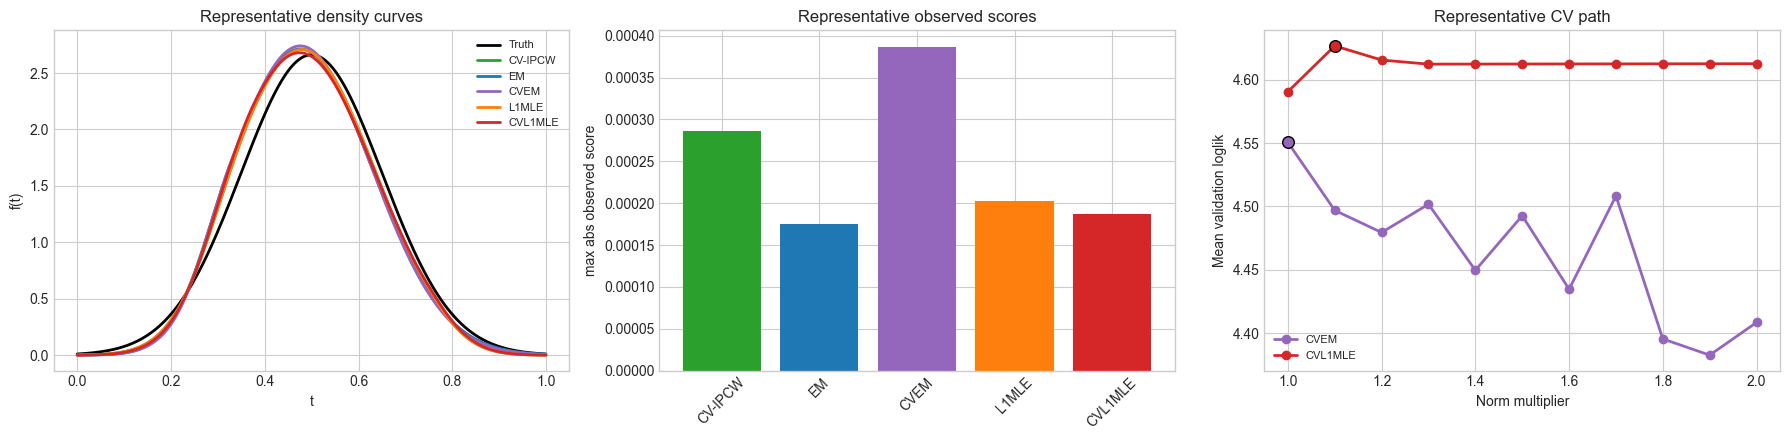

,t,truth,cv_ipcw,em,cvem,l1mle,cvl1mle
0,0.25,0.952598,0.961746,0.964957,0.966000,0.961822,0.963708
1,0.50,0.500000,0.461804,0.458084,0.456085,0.462192,0.459973
2,0.75,0.047402,0.034194,0.038787,0.036555,0.034263,0.036145


In [4]:
# Representative plots.

plot_grid = np.linspace(0.001, 0.999, 400)
method_color_map = {
    "CV-IPCW": "tab:green",
    "EM": "tab:blue",
    "CVEM": "tab:purple",
    "L1MLE": "tab:orange",
    "CVL1MLE": "tab:red",
}
method_estimator_map = {
    "CV-IPCW": stage1_estimator,
    "EM": em_run["estimator"],
    "CVEM": cvem_run["estimator"],
    "L1MLE": l1_run["estimator"],
    "CVL1MLE": cvl1_run["estimator"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(plot_grid, truth["density_fn"](plot_grid), color="black", linewidth=2, label="Truth")
for method in plot_method_order:
    axes[0].plot(
        plot_grid,
        method_estimator_map[method].get_density_at_points(plot_grid),
        color=method_color_map[method],
        linewidth=2,
        label=method,
    )
axes[0].set_title("Representative density curves")
axes[0].set_xlabel("t")
axes[0].set_ylabel("f(t)")
axes[0].legend(fontsize=8)

rep_plot_df = representative_df.copy()
bar_colors = [method_color_map[method] for method in rep_plot_df["method"].astype(str)]
axes[1].bar(rep_plot_df["method"].astype(str), rep_plot_df["max_abs_observed_score"], color=bar_colors)
axes[1].set_title("Representative observed scores")
axes[1].set_ylabel("max abs observed score")
axes[1].tick_params(axis="x", rotation=45)

for method_name, path_df, best_factor in [
    ("CVEM", cvem_run["cv_path_df"], cvem_run["best_em_norm_factor"]),
    ("CVL1MLE", cvl1_run["cv_path_df"], cvl1_run["best_norm_factor"]),
]:
    axes[2].plot(
        path_df["norm_factor"],
        path_df["mean_cv_loglik"],
        color=method_color_map[method_name],
        linewidth=2,
        marker="o",
        label=method_name,
    )
    best_df = path_df[np.isclose(path_df["norm_factor"], float(best_factor))]
    if not best_df.empty:
        axes[2].scatter(
            best_df["norm_factor"],
            best_df["mean_cv_loglik"],
            color=method_color_map[method_name],
            edgecolor="black",
            s=70,
            zorder=3,
        )
axes[2].set_title("Representative CV path")
axes[2].set_xlabel("Norm multiplier")
axes[2].set_ylabel("Mean validation loglik")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

survival_snapshot = pd.DataFrame(
    {
        "t": [0.25, 0.5, 0.75],
        "truth": truth["survival_fn"](np.array([0.25, 0.5, 0.75])),
        "cv_ipcw": evaluate_survival_on_grid(stage1_estimator, np.array([0.25, 0.5, 0.75])),
        "em": evaluate_survival_on_grid(em_run["estimator"], np.array([0.25, 0.5, 0.75])),
        "cvem": evaluate_survival_on_grid(cvem_run["estimator"], np.array([0.25, 0.5, 0.75])),
        "l1mle": evaluate_survival_on_grid(l1_run["estimator"], np.array([0.25, 0.5, 0.75])),
        "cvl1mle": evaluate_survival_on_grid(cvl1_run["estimator"], np.array([0.25, 0.5, 0.75])),
    }
)
display(survival_snapshot)


In [5]:
# Small-MC sweep in parallel.

with tqdm_joblib(tqdm(total=len(SEED_SWEEP), desc=f"Small MC sweep ({N_WORKERS} workers)")):
    seed_results = Parallel(n_jobs=N_WORKERS, backend="loky")(
        delayed(run_small_mc_seed)(seed) for seed in SEED_SWEEP
    )

method_rows = [row for result in seed_results for row in result["method_rows"]]
pointwise_rows = [row for result in seed_results for row in result["pointwise_rows"]]

method_summary = pd.DataFrame(method_rows)
method_summary["method"] = pd.Categorical(
    method_summary["method"], categories=plot_method_order, ordered=True
)
method_summary = method_summary.sort_values(["seed", "method"]).reset_index(drop=True)

method_median_summary = (
    method_summary.groupby("method", as_index=False, observed=False)
    .agg(
        n_seeds=("seed", "size"),
        median_runtime_seconds=("runtime_seconds", "median"),
        median_observed_loglik=("observed_loglik", "median"),
        median_max_abs_observed_score=("max_abs_observed_score", "median"),
        median_density_pointwise_mse=("density_pointwise_mse", "median"),
        median_survival_pointwise_mse=("survival_pointwise_mse", "median"),
        median_cv_norm_factor=("cv_norm_factor", "median"),
        median_best_cv_loglik=("best_cv_loglik", "median"),
    )
)
method_median_summary["median_runtime_ms"] = 1000.0 * method_median_summary["median_runtime_seconds"]

selected_factor_summary = (
    method_summary[method_summary["method"].isin(["CVEM", "CVL1MLE"])]
    .groupby(["method", "cv_norm_factor"], observed=False)
    .size()
    .reset_index(name="n_seeds")
    .sort_values(["method", "cv_norm_factor"])
    .reset_index(drop=True)
)

pointwise_summary = pd.DataFrame(pointwise_rows).sort_values(
    ["estimand", "method", "eval_point", "seed"]
).reset_index(drop=True)

pointwise_metric_rows = []
for (method, estimand, eval_point), group in pointwise_summary.groupby(
    ["method", "estimand", "eval_point"],
    sort=True,
):
    estimates = group["estimate"].to_numpy(dtype=float)
    truth_value = float(group["truth"].iloc[0])
    mean_estimate = float(np.mean(estimates))
    bias = float(mean_estimate - truth_value)
    variance = float(np.mean((estimates - mean_estimate) ** 2))
    mse = float(np.mean(np.square(estimates - truth_value)))
    pointwise_metric_rows.append(
        {
            "method": method,
            "estimand": estimand,
            "eval_point": float(eval_point),
            "truth": truth_value,
            "mean_estimate": mean_estimate,
            "bias": bias,
            "variance": variance,
            "mse": mse,
        }
    )

pointwise_metric_summary = pd.DataFrame(pointwise_metric_rows)
pointwise_metric_summary["method"] = pd.Categorical(
    pointwise_metric_summary["method"], categories=plot_method_order, ordered=True
)
pointwise_metric_summary = pointwise_metric_summary.sort_values(
    ["estimand", "method", "eval_point"]
).reset_index(drop=True)

pointwise_metric_overview = (
    pointwise_metric_summary.groupby(["method", "estimand"], as_index=False, observed=False)
    .agg(
        mean_abs_bias=("bias", lambda s: float(np.mean(np.abs(np.asarray(s, dtype=float))))),
        mean_variance=("variance", "mean"),
        mean_mse=("mse", "mean"),
    )
)

display(method_median_summary)
display(selected_factor_summary)
display(pointwise_metric_overview)


Small MC sweep (10 workers):   0%|          | 0/100 [00:00<?, ?it/s]/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try anoth

,method,n_seeds,median_runtime_seconds,median_observed_loglik,median_max_abs_observed_score,median_density_pointwise_mse,median_survival_pointwise_mse,median_cv_norm_factor,median_best_cv_loglik,median_runtime_ms
0,CV-IPCW,100,7.139453,0.113981,0.001015,0.049520,0.000544,NaN,NaN,7139.452959
1,EM,100,0.173860,0.115148,0.000650,0.045940,0.000479,1.00,NaN,173.859646
2,CVEM,100,8.984204,0.118186,0.000593,0.056556,0.000498,1.15,3.821962,8984.204271
3,L1MLE,100,0.005204,0.115133,0.000220,0.049788,0.000524,1.00,NaN,5.203646
4,CVL1MLE,100,1.270848,0.116408,0.000159,0.050831,0.000521,1.10,3.939483,1270.847583


,method,cv_norm_factor,n_seeds
0,CV-IPCW,1.0,0
1,CV-IPCW,1.1,0
2,CV-IPCW,1.2,0
3,CV-IPCW,1.3,0
4,CV-IPCW,1.4,0
5,CV-IPCW,1.5,0
6,CV-IPCW,1.6,0
7,CV-IPCW,1.7,0
8,CV-IPCW,1.8,0
9,CV-IPCW,1.9,0


,method,estimand,mean_abs_bias,mean_variance,mean_mse
0,CV-IPCW,density,0.082989,0.132835,0.143544
1,CV-IPCW,survival,0.014633,0.002665,0.002980
2,EM,density,0.100020,0.131238,0.144239
3,EM,survival,0.016173,0.002545,0.002860
4,CVEM,density,0.081530,0.125942,0.134706
5,CVEM,survival,0.013041,0.002175,0.002380
6,L1MLE,density,0.100470,0.132260,0.145907
7,L1MLE,survival,0.016281,0.002550,0.002869
8,CVL1MLE,density,0.081380,0.123050,0.132117
9,CVL1MLE,survival,0.013132,0.002167,0.002374


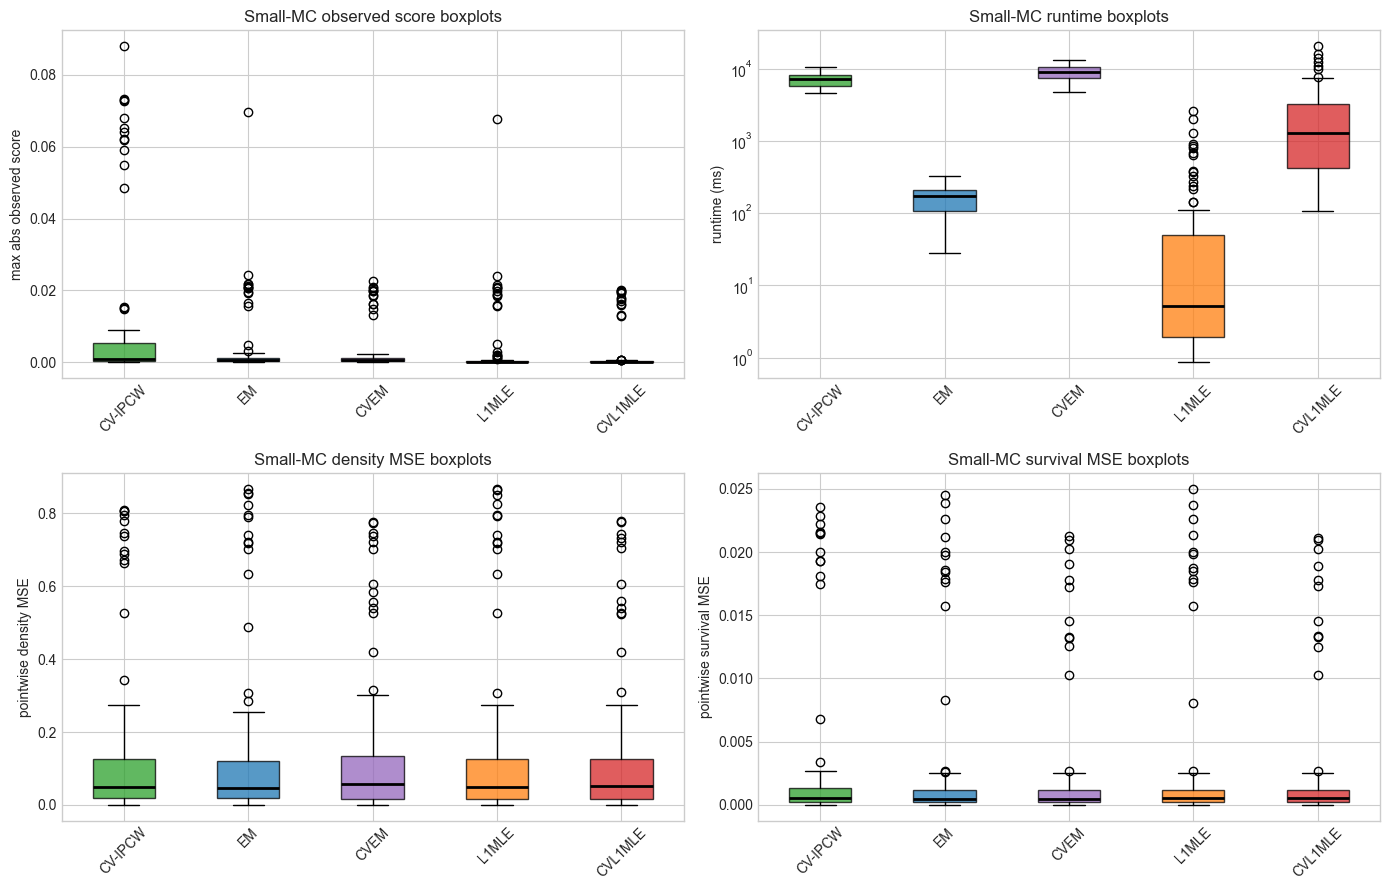

In [6]:
# Small-MC score, runtime, and MSE boxplots.

boxplot_methods = plot_method_order
boxplot_colors = method_color_map
plot_method_summary = method_summary.copy()


def boxplot_values(column: str) -> list[np.ndarray]:
    values_by_method = []
    for method in boxplot_methods:
        values = plot_method_summary.loc[
            plot_method_summary["method"] == method, column
        ].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        values_by_method.append(values if values.size else np.array([np.nan]))
    return values_by_method


observed_box_data = boxplot_values("max_abs_observed_score")
runtime_box_data = boxplot_values("runtime_ms")
density_mse_box_data = boxplot_values("density_pointwise_mse")
survival_mse_box_data = boxplot_values("survival_pointwise_mse")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
observed_box = axes[0, 0].boxplot(observed_box_data, tick_labels=boxplot_methods, patch_artist=True)
runtime_box = axes[0, 1].boxplot(runtime_box_data, tick_labels=boxplot_methods, patch_artist=True)
density_mse_box = axes[1, 0].boxplot(density_mse_box_data, tick_labels=boxplot_methods, patch_artist=True)
survival_mse_box = axes[1, 1].boxplot(survival_mse_box_data, tick_labels=boxplot_methods, patch_artist=True)

for boxplot in [observed_box, runtime_box, density_mse_box, survival_mse_box]:
    for patch, method in zip(boxplot["boxes"], boxplot_methods):
        patch.set_facecolor(boxplot_colors[method])
        patch.set_alpha(0.75)
    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

axes[0, 0].set_title("Small-MC observed score boxplots")
axes[0, 0].set_ylabel("max abs observed score")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].set_title("Small-MC runtime boxplots")
axes[0, 1].set_ylabel("runtime (ms)")
axes[0, 1].set_yscale("log")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].set_title("Small-MC density MSE boxplots")
axes[1, 0].set_ylabel("pointwise density MSE")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].set_title("Small-MC survival MSE boxplots")
axes[1, 1].set_ylabel("pointwise survival MSE")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

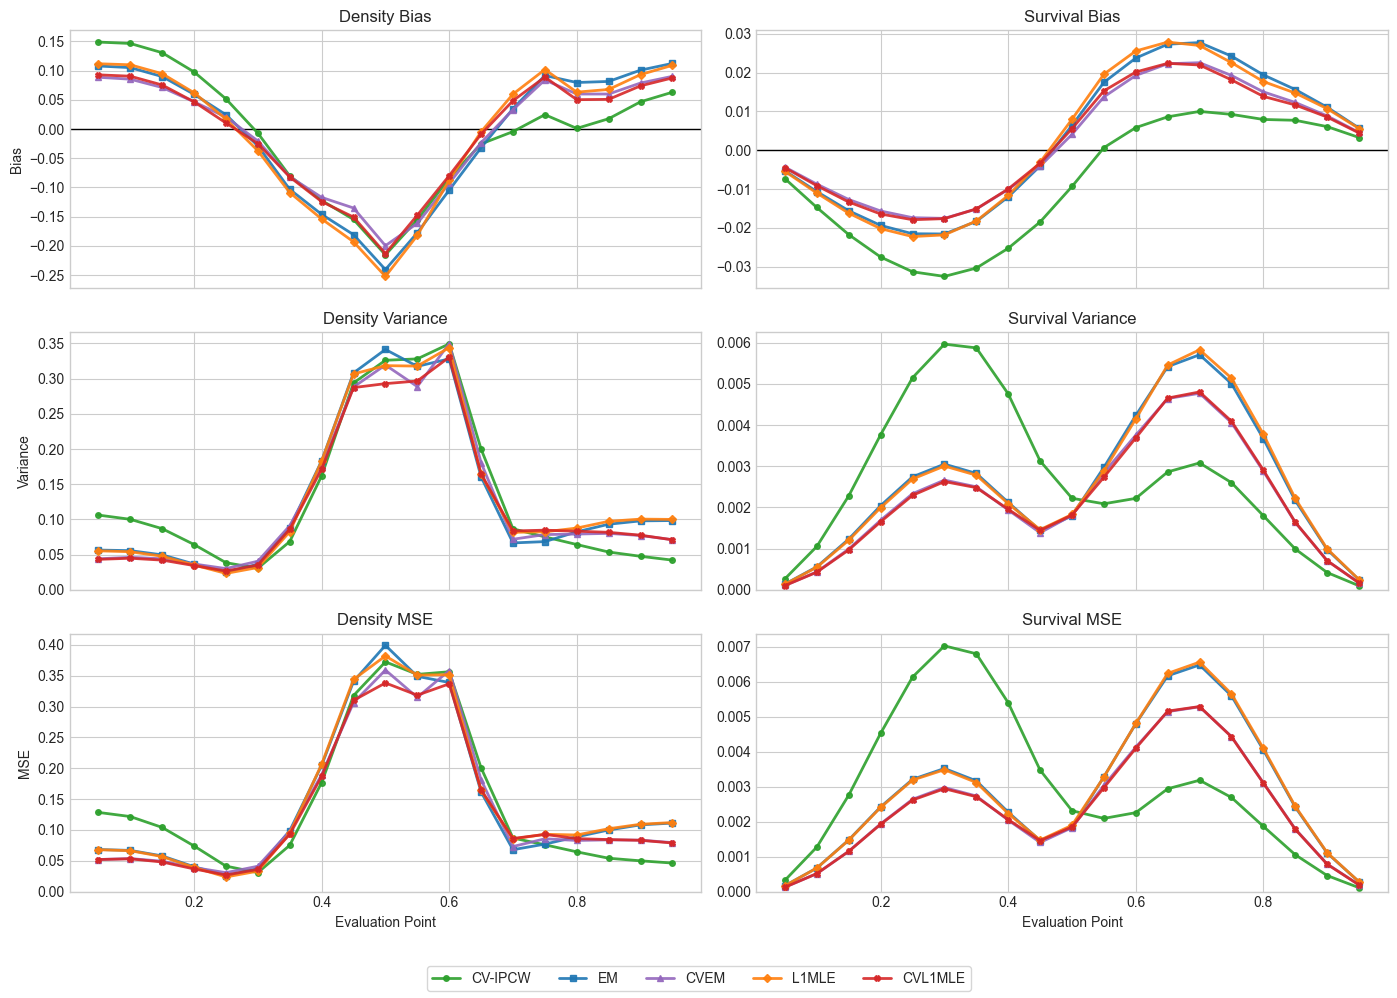

In [7]:
# Small-MC pointwise bias, variance, and MSE line plots.

pointwise_plot_methods = plot_method_order
pointwise_plot_colors = method_color_map
pointwise_plot_markers = {
    "CV-IPCW": "o",
    "EM": "s",
    "CVEM": "^",
    "L1MLE": "D",
    "CVL1MLE": "X",
}
metric_order = ["bias", "variance", "mse"]
estimand_order = ["density", "survival"]
metric_labels = {"bias": "Bias", "variance": "Variance", "mse": "MSE"}
estimand_labels = {"density": "Density", "survival": "Survival"}

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex="col")

for row_idx, metric in enumerate(metric_order):
    for col_idx, estimand in enumerate(estimand_order):
        ax = axes[row_idx, col_idx]
        if metric == "bias":
            ax.axhline(0.0, color="black", linewidth=1)

        for method in pointwise_plot_methods:
            method_df = pointwise_metric_summary[
                (pointwise_metric_summary["method"] == method)
                & (pointwise_metric_summary["estimand"] == estimand)
            ].sort_values("eval_point")
            ax.plot(
                method_df["eval_point"],
                method_df[metric],
                color=pointwise_plot_colors[method],
                linewidth=2,
                marker=pointwise_plot_markers[method],
                markersize=4,
                alpha=0.9,
                label=method,
            )

        ax.set_title(f"{estimand_labels[estimand]} {metric_labels[metric]}")
        if col_idx == 0:
            ax.set_ylabel(metric_labels[metric])
        if row_idx == len(metric_order) - 1:
            ax.set_xlabel("Evaluation Point")
        if metric in {"variance", "mse"}:
            ax.set_ylim(bottom=0.0)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(pointwise_plot_methods), frameon=True)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()


## Oracle-SD Coverage

This section reuses the same small-MC sweep and computes pointwise 95% coverage using the empirical Monte Carlo SD as an oracle standard error.

For survival, both linear and log-log interval coverage are shown so the post-IPCW centering behavior of the fixed and CV-tuned EM and L1 refits can be compared without mixing in standard-error estimation error. A true event-time KM baseline is also included for survival only.

,method,estimand,mean_oracle_sd,mean_abs_bias_over_sd,mean_linear_oracle_coverage,mean_loglog_oracle_coverage
0,CV-IPCW,density,0.338302,0.236788,0.908947,NaN
1,EM,density,0.335620,0.296304,0.905263,NaN
2,CVEM,density,0.328167,0.250267,0.906316,NaN
3,L1MLE,density,0.337198,0.298993,0.901579,NaN
4,CVL1MLE,density,0.324814,0.252125,0.902632,NaN
5,CV-IPCW,survival,0.048047,0.298672,0.898421,0.893684
6,EM,survival,0.047186,0.346395,0.896316,0.893158
7,CVEM,survival,0.043513,0.308582,0.898421,0.897895
8,L1MLE,survival,0.047190,0.350329,0.894211,0.894211
9,CVL1MLE,survival,0.043425,0.312955,0.898947,0.897368


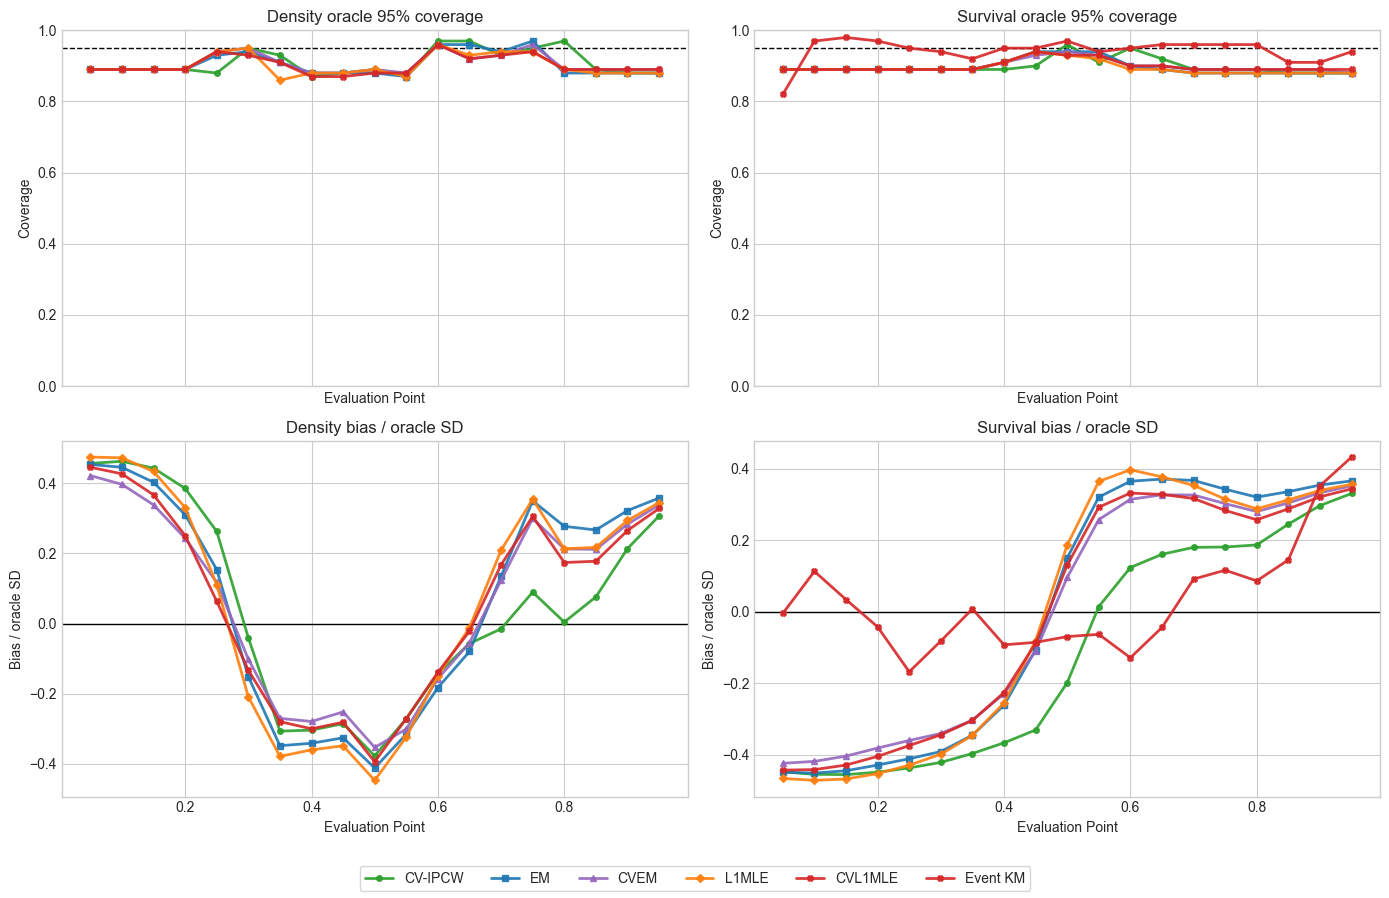

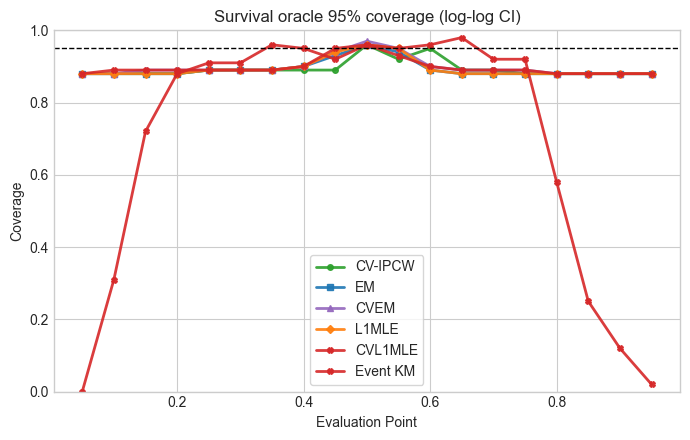

In [8]:
# Small-MC oracle-SD coverage and bias-over-SD summaries.

def nanmean_or_nan(values, *, absolute: bool = False) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if absolute:
        arr = np.abs(arr)
    return float(np.mean(arr)) if arr.size else float("nan")


def oracle_survival_loglog_ci(
    survival: np.ndarray,
    standard_error: np.ndarray,
    *,
    z: float = 1.96,
) -> tuple[np.ndarray, np.ndarray]:
    eps = 1e-10
    s = np.asarray(survival, dtype=float)
    se = np.asarray(standard_error, dtype=float)
    lower = np.full(s.shape, np.nan, dtype=float)
    upper = np.full(s.shape, np.nan, dtype=float)

    def inv_loglog(g_value: float) -> float:
        if g_value >= 700.0:
            return 0.0
        if g_value <= -745.0:
            return 1.0
        return float(np.exp(-np.exp(g_value)))

    for i, (si, sei) in enumerate(zip(s, se, strict=False)):
        if not np.isfinite(si):
            continue
        if si <= 0.0:
            lower[i] = 0.0
            upper[i] = 0.0
            continue
        if si >= 1.0:
            lower[i] = 1.0
            upper[i] = 1.0
            continue

        s_clip = float(np.clip(si, eps, 1.0 - eps))
        if not np.isfinite(sei) or sei < 0.0:
            lower[i] = 0.0
            upper[i] = 1.0
            continue

        log_s = float(np.log(s_clip))
        denom = float(s_clip * abs(log_s))
        if denom <= 0.0:
            lower[i] = 0.0
            upper[i] = 1.0
            continue

        se_g = float(sei / denom)
        g_hat = float(np.log(-log_s))
        g_lo = g_hat - z * se_g
        g_hi = g_hat + z * se_g
        lower[i] = float(np.clip(inv_loglog(g_hi), 0.0, 1.0))
        upper[i] = float(np.clip(inv_loglog(g_lo), 0.0, 1.0))

    return lower, upper


def event_time_km_survival(
    data: pd.DataFrame,
    grid: np.ndarray,
    *,
    time_col: str = "T",
    delta_col: str = "Delta",
) -> np.ndarray:
    y = np.asarray(data[time_col].values, dtype=float).ravel()
    delta = np.asarray(data[delta_col].values, dtype=int).ravel()

    order = np.argsort(y)
    y_sorted = y[order]
    delta_sorted = delta[order]

    unique_times, idx_start = np.unique(y_sorted, return_index=True)
    counts_at_time = np.diff(np.append(idx_start, len(y_sorted)))
    events_at_time = np.add.reduceat(delta_sorted, idx_start)
    at_risk = len(y_sorted) - np.cumsum(np.append(0, counts_at_time[:-1]))

    frac = np.clip(1.0 - (events_at_time / np.maximum(at_risk, 1)), 0.0, 1.0)
    surv = np.cumprod(frac, dtype=float)

    eval_grid = np.asarray(grid, dtype=float)
    idx = np.searchsorted(unique_times, eval_grid, side="right") - 1
    idx = np.clip(idx, -1, len(unique_times) - 1)
    return np.where(idx >= 0, surv[idx], 1.0)


oracle_summary_method_order = [*plot_method_order, "Event KM"]
oracle_method_color_map = dict(method_color_map)
oracle_method_color_map["Event KM"] = "tab:red"

oracle_pointwise_rows = list(pointwise_summary.to_dict(orient="records"))
eval_grid = np.asarray(POINTWISE_MSE_GRID, dtype=float)
for seed in SEED_SWEEP:
    simulation_seed = simulate_reference_right_censored_dgp(n=N, seed=seed)
    data_seed = simulation_seed["observed_data"]
    truth_seed = simulation_seed["truth"]
    km_survival = event_time_km_survival(data_seed, eval_grid)
    truth_survival = np.asarray(truth_seed["survival_fn"](eval_grid), dtype=float)
    for eval_point, estimate, truth_value in zip(
        eval_grid, km_survival, truth_survival, strict=False
    ):
        error = float(estimate - truth_value)
        oracle_pointwise_rows.append(
            {
                "seed": int(seed),
                "method": "Event KM",
                "estimand": "survival",
                "eval_point": float(eval_point),
                "estimate": float(estimate),
                "truth": float(truth_value),
                "error": error,
                "squared_error": float(error ** 2),
            }
        )

oracle_pointwise_summary = pd.DataFrame(oracle_pointwise_rows).sort_values(
    ["estimand", "method", "eval_point", "seed"]
).reset_index(drop=True)

oracle_interval_rows = []
for (method, estimand, eval_point), group in oracle_pointwise_summary.groupby(
    ["method", "estimand", "eval_point"],
    sort=True,
    observed=False,
):
    estimates = group["estimate"].to_numpy(dtype=float)
    truth_value = float(group["truth"].iloc[0])
    mean_estimate = float(np.mean(estimates))
    bias = float(mean_estimate - truth_value)
    oracle_sd = float(np.std(estimates, ddof=0))
    bias_over_sd = (
        float(bias / oracle_sd)
        if np.isfinite(oracle_sd) and oracle_sd > 1e-12
        else float("nan")
    )
    linear_coverage = float(np.mean(np.abs(estimates - truth_value) <= (1.96 * oracle_sd)))

    loglog_coverage = float("nan")
    if str(estimand) == "survival":
        loglog_lo, loglog_hi = oracle_survival_loglog_ci(
            survival=estimates,
            standard_error=np.full(estimates.shape, oracle_sd, dtype=float),
        )
        loglog_coverage = float(np.mean((truth_value >= loglog_lo) & (truth_value <= loglog_hi)))

    oracle_interval_rows.append(
        {
            "method": method,
            "estimand": estimand,
            "eval_point": float(eval_point),
            "n_seeds": int(group["seed"].nunique()),
            "truth": truth_value,
            "mean_estimate": mean_estimate,
            "bias": bias,
            "oracle_sd": oracle_sd,
            "bias_over_sd": bias_over_sd,
            "oracle_ci_coverage": linear_coverage,
            "oracle_ci_coverage_loglog": loglog_coverage,
        }
    )

oracle_interval_summary = pd.DataFrame(oracle_interval_rows)
oracle_interval_summary["method"] = pd.Categorical(
    oracle_interval_summary["method"], categories=oracle_summary_method_order, ordered=True
)
oracle_interval_summary = oracle_interval_summary.sort_values(
    ["estimand", "method", "eval_point"]
).reset_index(drop=True)

oracle_metric_overview = (
    oracle_interval_summary.groupby(["method", "estimand"], observed=True)
    .agg(
        mean_oracle_sd=("oracle_sd", "mean"),
        mean_abs_bias_over_sd=("bias_over_sd", lambda s: nanmean_or_nan(s, absolute=True)),
        mean_linear_oracle_coverage=("oracle_ci_coverage", nanmean_or_nan),
        mean_loglog_oracle_coverage=("oracle_ci_coverage_loglog", nanmean_or_nan),
    )
    .reset_index()
)
oracle_metric_overview["method"] = pd.Categorical(
    oracle_metric_overview["method"], categories=oracle_summary_method_order, ordered=True
)
oracle_metric_overview = oracle_metric_overview.sort_values(
    ["estimand", "method"]
).reset_index(drop=True)

display(oracle_metric_overview)

oracle_plot_markers = (
    dict(pointwise_plot_markers)
    if "pointwise_plot_markers" in globals()
    else {method: "o" for method in oracle_summary_method_order}
)
oracle_plot_markers["Event KM"] = "X"

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex="col")
plot_specs = [
    ("density", "oracle_ci_coverage", "Density oracle 95% coverage", 0.95),
    ("survival", "oracle_ci_coverage", "Survival oracle 95% coverage", 0.95),
    ("density", "bias_over_sd", "Density bias / oracle SD", 0.0),
    ("survival", "bias_over_sd", "Survival bias / oracle SD", 0.0),
]

for ax, (estimand, metric, title, reference) in zip(axes.flat, plot_specs, strict=True):
    if metric == "oracle_ci_coverage":
        ax.axhline(reference, color="black", linewidth=1, linestyle="--")
        ax.set_ylim(0.0, 1.0)
    else:
        ax.axhline(reference, color="black", linewidth=1)

    panel_methods = oracle_summary_method_order if estimand == "survival" else plot_method_order
    for method in panel_methods:
        method_df = oracle_interval_summary[
            (oracle_interval_summary["method"] == method)
            & (oracle_interval_summary["estimand"] == estimand)
        ].sort_values("eval_point")
        if method_df.empty:
            continue
        ax.plot(
            method_df["eval_point"],
            method_df[metric],
            color=oracle_method_color_map[method],
            linewidth=2,
            marker=oracle_plot_markers[method],
            markersize=4,
            alpha=0.9,
            label=method,
        )

    ax.set_title(title)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("Coverage" if metric == "oracle_ci_coverage" else "Bias / oracle SD")

handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=True)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
for method in oracle_summary_method_order:
    method_df = oracle_interval_summary[
        (oracle_interval_summary["method"] == method)
        & (oracle_interval_summary["estimand"] == "survival")
    ].sort_values("eval_point")
    if method_df.empty:
        continue
    ax.plot(
        method_df["eval_point"],
        method_df["oracle_ci_coverage_loglog"],
        color=oracle_method_color_map[method],
        linewidth=2,
        marker=oracle_plot_markers[method],
        markersize=4,
        alpha=0.9,
        label=method,
    )

ax.axhline(0.95, color="black", linewidth=1, linestyle="--")
ax.set_ylim(0.0, 1.0)
ax.set_title("Survival oracle 95% coverage (log-log CI)")
ax.set_xlabel("Evaluation Point")
ax.set_ylabel("Coverage")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## Takeaways

This notebook now carries both fixed and CV-tuned post-IPCW refinements in the same Monte Carlo comparison:

- `CV-IPCW` is the shared initializer.
- `EM` and `L1MLE` are the inherited-constraint factor-1.0 baselines.
- `CVEM` and `CVL1MLE` both search over the same deterministic norm-multiplier grid on `[1, 2]`.
- The small-MC summaries therefore show whether the CV-tuned post-IPCW refinements actually improve on their fixed-constraint counterparts.

If the CV-tuned versions keep showing gains here, the next step is to promote the notebook-local `CVL1MLE` path logic into `src/` as a package tuner.